<a href="https://colab.research.google.com/github/100522094/aprendizaje-p1-100522234-100522094/blob/main/parte1_100522094_100522234.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRIMERA PRÁCTICA - ENTRENAMENTO Y ANÁLISIS DEL MODELO**

### **PREDICCIÓN DE SUBSCRIPCIÓN A UN PRODUCTO BANCARIO - Cuaderno 1**

### **Aprendizaje Automático - Grado en Ingeniería Informática - Curso 2025/26**

### **Autores**

<img src="https://www.elearningmedia.es/sites/default/files/inline-images/logo_UC3M.png" align="right" width="200" style="margin-left: 20px;">

Grupo 82 - Equipo 05

- Carmen Peláez Martín - 100522094
- Ana Sanz del Collado - 100522234


Link repositorio Git Hub:

https://github.com/100522094/aprendizaje-p1-100522234-100522094


Antes de comenzar, forzamos la versión de scikit-learn para asegurar que es compatible con el modelo guardado .pkl

**IMPORTANTE**: Asegurate de que el achivo "bank_07.pkl" está cargado correctamente

In [ ]:
!pip install scikit-learn==1.8.0


# **Fase 2: Análisis Exploratorio de Datos (EDA) Simplificado**

En esta fase hemos realizado un Analisis Exploratorio de Datos (DEA) para entender, conocer y analizar la estructura de nuestro dataset antes de aplicar metodos de aprendizaje automatico.

El objetivo es identificar problemas como valores faltantes, alta cardinalidad o desbalanceo de clases, que pueden afectar al rendimiento de los algoritmos KNN y arboles de decisión que entrenaremos más adelante.

## Paso 1: Importar las librerías y cargar los datos


In [ ]:
# importamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# cargamos el dataset
df = pd.read_pickle('bank_07.pkl')

# intentamos ver las primeras filas para familiarizarnos con los datos
print("\nPrimeras 5 filas del dataset:\n")
display(df.head())


Primeras 5 filas del dataset:



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Paso 2: Inspección de los datos (variables e instancias)

In [ ]:
print(f"Dimensiones del dataset: {df.shape[0]} instancias y {df.shape[1]} variables")

# determinamos los tipos de variables (como en los tutoriales)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nVariables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

# buscamos:
# columnas constantes (siempre el mismo valor)
cols_constantes = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nColumnas constantes encontradas: {cols_constantes}")

# columnas tipo ID (columna con tantos valores diferentes como filas en el dataset)
total_filas = len(df)
cols_id = [col for col in df.columns if df[col].nunique() == total_filas]
print(f"Columnas tipo ID encontradas: {cols_id}")

# conclusion impresa por pantalla
if not cols_constantes and not cols_id:
    print("\nNo hay columnas inútiles (ni constantes ni IDs) en nuestro dataset")




Dimensiones del dataset: 11000 instancias y 17 variables

Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

Columnas constantes encontradas: []
Columnas tipo ID encontradas: []

No hay columnas inútiles (ni constantes ni IDs) en nuestro dataset



Hemos clasificado las variables en numéricas y categóricas para aplicar el preprocesamiento adecuado a cada grupo

No se han detectado columnas de ID ni columnas constantes, por lo que todas las variables contienen, en principio, información potencialmente útil para el modelo

## Paso 3: Cardinalidad y nulos


In [ ]:
# buscamos variables con alta cardinalidad (>10)
print("\nAnálisis de cardinalidad alta (mayor que 10):")
for col in cat_cols:
    n_unique = df[col].nunique()
    if n_unique > 10:
        print(f" - {col}: {n_unique} valores únicos")

# valores faltantes
missing = df.isnull().sum()
print("\nValores faltantes encontrados y su tipo de dato:")
print(missing[missing > 0])


Análisis de cardinalidad alta (mayor que 10):
 - job: 12 valores únicos
 - month: 12 valores únicos

Valores faltantes encontrados y su tipo de dato:
job    340
dtype: int64


Al analizar la cardinalidad, observamos que las variables `job` y `month` superan los 10 valores únicos. Esto es un punto crítico, ya que al aplicar técnicas de codificación, puede aumentar la dimensionalidad del dataset

Respecto a la calidad de los datos, solo la variable `job` presenta valores nulos (340). Estos valores deberán ser tratados diferente para no perder esas instancias

## Paso 4: Balanceo de Clase (problema de clasificación)



Distribución de la variable objetivo:
deposit
no     5780
yes    5220
Name: count, dtype: int64




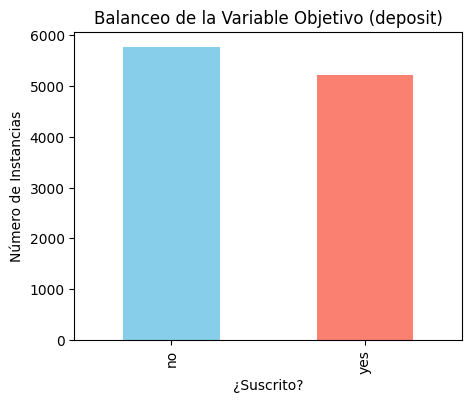

In [ ]:
# analizamos la variable objetivo 'deposit'
target_counts = df['deposit'].value_counts()
target_pct = df['deposit'].value_counts(normalize=True) * 100

print("\nDistribución de la variable objetivo:")
print(target_counts)
print("\n")

# vemos el grafico con Matplotlib (incluido en los apuntes de arboles)
plt.figure(figsize=(5, 4))
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Balanceo de la Variable Objetivo (deposit)')
plt.ylabel('Número de Instancias')
plt.xlabel('¿Suscrito?')
plt.show()

La variable objetivo deposit muestra una distribución de 52.5% (no) frente a 47.5% (yes)

Al estar las clases tan equilibradas, confirmamos que estamos ante un problema de clasificación balanceado. Esto nos permite utilizar la Exactitud (Accuracy) como métrica principal de evaluación sin riesgo de obtener resultados engañosos por sesgo de clase

## Paso 5: Análisis específico de la variable "pdays"


Registros en 'pdays' con valor -1: 8203 (74.57%)




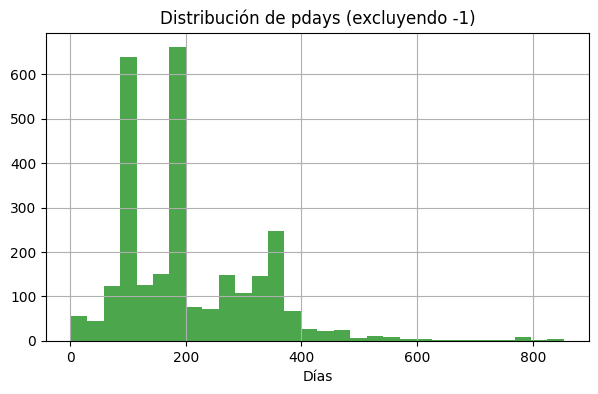

In [ ]:
# el valor -1 indica que ha habido contacto previo
pdays_val = df['pdays'].value_counts().get(-1, 0)
print(f"\nRegistros en 'pdays' con valor -1: {pdays_val} ({pdays_val/len(df)*100:.2f}%)")
print("\n")

# histograma de pdays para los que si fueron contactados
plt.figure(figsize=(7, 4))
df[df['pdays'] != -1]['pdays'].hist(bins=30, color='green', alpha=0.7)
plt.title('Distribución de pdays (excluyendo -1)')
plt.xlabel('Días')
plt.show()

La variable `pdays` (días desde el último contacto) requiere un tratamiento especial

Hemos detectado que el 74.57% de los registros tienen el valor -1. Según la documentación, esto indica que el cliente nunca fue contactado anteriormente

Tratar -1 como un valor numérico sería un error, ya que no representa una cantidad real en la misma escala que el resto. Para la siguiente fase, proponemos crear una variable binaria que distinga entre 'clientes nuevos' y 'clientes contactados previamente', permitiendo al modelo capturar esta distinción de forma clara

In [ ]:
# como hemos explicado, creamos una variable binaria para 'pdays' porque
# el valor -1 no tiene magnitud numerica real, sino que representa otra
# categoría:

# 0 = nunca contactado (-1)
# 1 = contactado previamente (>0)

df['was_previously_contacted'] = (df['pdays'] != -1).astype(int)

print("Nueva variable 'was_previously_contacted' creada con éxito.")
# mostramos una prueba de que funciona como queríamos
print(df[['pdays', 'was_previously_contacted']].head(3))


Nueva variable 'was_previously_contacted' creada con éxito.
   pdays  was_previously_contacted
0     -1                         0
1     -1                         0
2     -1                         0


## Conclusiones de la fase 2

Como conclusión de esta Fase 2 destacamos que:

  1. El dataset está limpio de nulos casi en su totalidad (salvo en `job`)
  2. No hay un desbalanceo que requiera técnicas de remuestreo
  3. El reto principal será la gestión de la alta cardinalidad en variables categóricas y el tratamiento no lineal de la variable `pdays`
  4. La  presencia de variables categóricas sugiere que los modelos basados en árboles podrían tener un buen desempeño inicial

# **Fase 3: Decidir la métrica y separar los datos (Train / Test)**



En esta fase definimos cómo vamos a evaluar los modelos a lo largo de toda la práctica.
Una buena estrategia de evaluación es fundamental para poder comparar métodos de forma justa y estimar de manera fiable cómo se comportará el modelo final con datos nuevos.



## Paso 1: Elección de la métrica

Para este problema de clasificación binaria utilizaremos **Accuracy** como métrica principal a lo largo de toda la práctica. Esta métrica mide la proporción de predicciones correctas sobre el total de instancias, lo que la hace directamente interpretable y fácilmente comparable entre modelos

Hemos considerado su uso debido a los resultados del EDA (Fase 2): la variable objetivo deposit presenta una distribución equilibrada
(52.5% no / 47.5% yes).
En problemas balanceados, Accuracy es una métrica adecuada y no produce resultados engañosos. En cambio, si las clases estuvieran muy desbalanceadas, sería preferible usar métricas como F1-score o ROC-AUC, que penalizan el sesgo hacia la clase mayoritaria. Al no ser ese nuestro caso, Accuracy es suficiente y apropiada

In [ ]:
from sklearn.model_selection import train_test_split

# eliminamos 'pdays' porque ya creamos 'was_previously_contacted'
X = df.drop(columns=['deposit', 'pdays'])
y = df['deposit']

# dividimos en train (2/3) y test (1/3)
# usamos stratify=y para mantener la proporcion de clases
SEED = 100522234

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=SEED,
    stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} instancias")
print(f"Tamaño del conjunto de test:          {X_test.shape[0]} instancias")
print(f"\nProporción de clases en train:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f"\nProporción de clases en test:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Tamaño del conjunto de entrenamiento: 7333 instancias
Tamaño del conjunto de test:          3667 instancias

Proporción de clases en train:
deposit
no     52.5
yes    47.5
Name: proportion, dtype: float64

Proporción de clases en test:
deposit
no     52.5
yes    47.5
Name: proportion, dtype: float64


Hemos dividido el dataset en dos particiones mutuamente excluyentes: entrenamiento (X_train, y_train) con 2/3 de los datos, y test (X_test, y_test) con el 1/3 restante. Se emplea el parámetro stratify=y para garantizar que la proporción de clases se mantiene igual en ambas particiones

El conjunto de test queda reservado desde este momento y no volverá a utilizarse hasta el final de la práctica. No se usará para entrenar modelos, ni para seleccionar hiperparámetros, ni para comparar alternativas. Utilizarlo antes de ese momento constituiría una filtración de información (data leakage): el modelo "vería" datos de test durante su desarrollo, lo que produciría estimaciones de rendimiento que no se corresponderían con el comportamiento real ante datos nuevos



## Paso 2: Evaluación inner

Para todo el trabajo intermedio de la práctica (comparación de modelos y optimización de hiperparámetros) utilizaremos Stratified K-Fold con 5 folds aplicado exclusivamente sobre el conjunto de entrenamiento. Esta evaluación inner tiene dos usos concretos en esta práctica:

1. **Comparar modelos**: para decidir qué método (KNN, árbol, SVM, etc.) funciona mejor, evaluaremos cada alternativa con este esquema de validación cruzada

2. **Optimización de hiperparámetros (HPO)**: para ajustar los hiperparámetros de cada modelo, también usaremos este mismo esquema, evitando así el sobreajuste al conjunto de validación

El método divide el train en 5 subconjuntos (folds). En cada iteración, el modelo se entrena con 4 folds y se evalúa en el fold restante, rotando hasta que todos han actuado como validación

El resultado final es la media de las 5 evaluaciones, lo que proporciona una estimación más robusta que una única partición train/validación. La versión estratificada garantiza además que cada fold conserva la misma proporción de clases que el conjunto original

In [ ]:
from sklearn.model_selection import StratifiedKFold

SEED = 100522234

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Estrategia de evaluación inner: Stratified K-Fold")
print(f"  - Número de folds: 5")
print(f"  - Shuffle: True")
print(f"  - Semilla: {SEED}")
print(f"\nMétrica principal: Accuracy")


Estrategia de evaluación inner: Stratified K-Fold
  - Número de folds: 5
  - Shuffle: True
  - Semilla: 100522234

Métrica principal: Accuracy


## Conclusiones de la fase 3

Como conclusión de esta Fase 3 destacamos que:

  1. **Holdout completado**: hemos dividido los datos en train (7.333 instancias) y test (3.667 instancias) en proporción 2/3-1/3, manteniendo la proporción de clases con stratify=y. Ambas particiones presentan exactamente la misma distribución (52.5% no/ 47.5% yes)

  2. **Test reservado**: la partición de test queda completamente reservada y no se usará hasta el paso final de evalucaión del modelo ganador

  3. **Inner CV configurado**: toda la comparación de modelos y la HPO se hará usando Stratified K-Fold (5 folds) sobre el conjunto de train, garantizando evalucaiones robustas y representativas

  4. **Métrica principal**: Accuracy, justificada por el equilibrio de clases del dataset. Se descartaron métricas como F1 o ROC-AUC al no existir desbalanceo relevante

  5. **Variables**: se eliminó pdays original del dataset, usando `was_previously_contacted` según decisión de Fase 2

  6. **Reproducibilidad**: semilla fijada con el NIA 100522234 en todas las operaciones aleatorias


# **Fase 4: Entrenar y Optimizar los métodos básicos: KNN y Árboles**

En esta fase comenzamos a entrenar los primeros modelos de aprendizaje automático sobre el problema dado

Trabajaremos con dos familias de modelos muy diferentes (cada uno requiere un procesamiento distinto y reacciona de forma diferente a los hiperparámetros):

1. **KNN**: que basa sus predicciones en la similitud entre instancias midiendo
distancias

2. **Árboles de decisión**: que aprenden reglas jerárquicas
sobre los valores de las variables

La implementación del preprocesamiento dentro de pipelines de scikit-learn garantiza que no haya fuga de información entre el train y la validación, y que el proceso sea reproducible y fácilmente exportable al modelo final

La evaluación de todos los experimentos de esta fase se realiza exclusivamente sobre el conjunto de entrenamiento, usando la validación cruzada inner definida en la Fase 3 (Stratified K-Fold, 5 folds)

## Paso 1: Imports y recuperación del estado anterior

Antes de comenzar con los modelos, cargamos todas las librerías necesarias para esta fase. Es importante que esta celda reproduzca exactamente el mismo split que en la Fase 3, usando la misma semilla (NIA), para que los resultados sean consistentes a lo largo de todo el cuaderno

In [ ]:
import pandas as pd                  # manejo de DataFrames
import numpy as np                   # operaciones numéricas y arrays
import matplotlib.pyplot as plt      # gráficos
import time                          # mide tiempos de entrenamiento

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# semilla y CV para reproducir exactamente la fase 3
SEED = 100522234
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# cargamos los datos
df = pd.read_pickle('bank_07.pkl')

# preproceso de pdays (Fase 2)
df['was_previously_contacted'] = (df['pdays'] != -1).astype(int) # var binaria: 1 si el cliente fue contactado antes, 0 si no
df['pdays_clean'] = df['pdays'].replace(-1, 0) # reemplazamos -1 (sin contacto) por 0

# eliminamos 'pdays' porque ya esta representada por las dos columnas anteriores
X = df.drop(columns=['deposit', 'pdays'])

# eliminamos 'deposit' porque es la variable que queremos predecir
y = df['deposit']

# holdout train/test (identico a la Fase 3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (7333, 17)  |  Test: (3667, 17)


## Paso 2: Construcción de los preprocesadores

Antes de entrenar cualquier modelo definimos cómo se transformarán las variables. KNN y los árboles de decisión tienen necesidades de preprocesamiento (transformar los datos a un formato que los algoritmos puedan procesar correctamente) muy distintas:

  - **KNN**: mide distancias entre instancias, por lo que variables con rangos muy distintos dominarían el cálculo si no se normalizan. Necesitan escalado

  - **Los árboles**: realizan divisiones binarias sobre los valores de cada variable de forma independiente, por lo que el escalado no afecta a sus resultados. No necesitan escalado

Por otro lado, scikit-learn no acepta strings ni NaNs como entrada por lo que ambos métodos sí necesitan que las variables categóricas estén codificadas numéricamente y que los valores nulos estén imputados. Para las variables numéricas usaremos la mediana y para las categóricas usaremos la moda (valor más frecuente)

In [ ]:
# identificar columnas por tipo
# separamos automaticamente segun el dtype del DataFrame
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Columnas numéricas:  ", num_cols)
print("Columnas categóricas:", cat_cols)

# transformador para variables categóricas
# encadena dos pasos dentro de un Pipeline:
#   1. SimpleImputer: rellena los nulos con la moda (valor mas frecuente)
#   2. OneHotEncoder: convierte cada categoria en una columna binaria (0/1)
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# funcion para construir preprocesadores con distinto escalado
# recibe un objeto scaler ya instanciado y devuelve un ColumnTransformer completo que aplica a cada grupo de columnas
# su transformacion correspondiente (numéricas o categóricas)
def make_preprocessor(scaler):
    num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  scaler)
    ])
    return ColumnTransformer([
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# tres preprocesadores, uno por cada metodo de escalado a comparar:

# MinMaxScaler:   lleva cada variable al rango [0, 1]
# StandardScaler: transforma a media 0 y desviación estándar 1 (z-score)
# RobustScaler:   usa la mediana y el rango intercuartilico (IQR) en lugar de media y desviación estandar
preprocessors = {
    'minmax':   make_preprocessor(MinMaxScaler()),
    'standard': make_preprocessor(StandardScaler()),
    'robust':   make_preprocessor(RobustScaler())
}

# preprocesador específico para arboles (sin escalado)
# los árboles no necesitan escalar (explicado en el texto de arriba)
tree_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', cat_transformer,                  cat_cols)
])

print("\nPreprocesadores construidos correctamente")

Columnas numéricas:   ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'was_previously_contacted', 'pdays_clean']
Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Preprocesadores construidos correctamente


## Paso 3: Decidir el método de escalado para KNN

Como hemos mencionado, KNN calcula distancias entre los puntos. Si una variable (como `balance`) tiene valores en los miles, y otra (como `age`) en las decenas, el algoritmo le dará muchísima más importancia al balance solo por ser un número más grande.

Para evitar esto, probaremos los tres escaladores definidos anteriormente evaluándolos mediante Validación Cruzada (Inner Evaluation) para ver cuál nos da mejor *Accuracy*.

In [ ]:
# USO DE IA: Ayuda en la comparación de los tres métodos de escalado (minmax, standard, robust) mediante bucle y cross_val_score.

print("Evaluando métodos de escalado para KNN (K=5 por defecto)...")
resultados_escaladores = {}

for nombre_escalador, preprocesador in preprocessors.items():
    # creamos el pipeline uniendo el preprocesador y el clasificador KNN
    pipeline_knn = Pipeline([
        ('prep', preprocesador),
        ('knn', KNeighborsClassifier()) # usamos hiperparametros por defecto
    ])

    # medimos el tiempo de validación cruzada
    inicio = time.time()
    # cv está definido en el Paso 1 (StratifiedKFold)
    scores = cross_val_score(pipeline_knn, X_train, y_train, cv=cv, scoring='accuracy')
    tiempo = time.time() - inicio

    # guardamos la media de accuracy y el tiempo
    resultados_escaladores[nombre_escalador] = {'accuracy': scores.mean(), 'tiempo': tiempo}
    print(f" - {nombre_escalador.capitalize()}: Accuracy = {scores.mean():.4f} | Tiempo = {tiempo:.2f}s")

# elegimos el mejor escalador automaticamente
mejor_escalador = max(resultados_escaladores, key=lambda k: resultados_escaladores[k]['accuracy'])
print(f"\n--- El mejor método de escalado para KNN es: {mejor_escalador.upper()}")

# finalmente, nos quedamos con el preprocesador ganador para el resto de la práctica
knn_preprocessor = preprocessors[mejor_escalador]



Evaluando métodos de escalado para KNN (K=5 por defecto)...
 - Minmax: Accuracy = 0.7402 | Tiempo = 1.03s
 - Standard: Accuracy = 0.7989 | Tiempo = 1.43s
 - Robust: Accuracy = 0.7824 | Tiempo = 1.71s

--- El mejor método de escalado para KNN es: STANDARD


## Paso 4: Modelos básicos por omisión y Modelos Triviales (Dummy)

Antes de intentar buscar los mejores hiperparámetros (HPO), necesitamos saber de dónde partimos. Para ello vamos a evaluar:
1. **Dummy Classifier:** Es un modelo "tonto" que predice usando reglas muy simples (por ejemplo, predecir siempre la clase mayoritaria o basándose en la proporción de las clases). Es nuestra línea base: cualquier modelo de Machine Learning que hagamos **debe** superar al Dummy.
2. **KNN (con el mejor escalador) por omisión.**
3. **Árbol de Decisión por omisión.**

In [ ]:
print("Evaluando modelos por omisión frente a Dummy Classifier...\n")

# 1. DUMMY CLASSIFIER
dummy_clf = DummyClassifier(strategy='prior') # predice siempre la clase mayoritaria
scores_dummy = cross_val_score(dummy_clf, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Dummy Classifier (Base): Accuracy = {scores_dummy.mean():.4f}")

# 2. KNN POR OMISIÓN
pipeline_knn_base = Pipeline([
    ('prep', knn_preprocessor),
    ('knn', KNeighborsClassifier())
])
inicio = time.time()
scores_knn_base = cross_val_score(pipeline_knn_base, X_train, y_train, cv=cv, scoring='accuracy')
t_knn_base = time.time() - inicio
print(f"KNN (Default)          : Accuracy = {scores_knn_base.mean():.4f} | Tiempo CV = {t_knn_base:.2f}s")

# 3. ÁRBOL DE DECISIÓN POR OMISIÓN
pipeline_tree_base = Pipeline([
    ('prep', tree_preprocessor),
    ('tree', DecisionTreeClassifier(random_state=SEED))
])
inicio = time.time()
scores_tree_base = cross_val_score(pipeline_tree_base, X_train, y_train, cv=cv, scoring='accuracy')
t_tree_base = time.time() - inicio
print(f"Tree (Default)         : Accuracy = {scores_tree_base.mean():.4f} | Tiempo CV = {t_tree_base:.2f}s")



Evaluando modelos por omisión frente a Dummy Classifier...

Dummy Classifier (Base): Accuracy = 0.5254
KNN (Default)          : Accuracy = 0.7989 | Tiempo CV = 1.83s
Tree (Default)         : Accuracy = 0.7784 | Tiempo CV = 2.54s


## Paso 5: Interpretación usando Árboles Poco Profundos

Una de las grandes ventajas de los árboles de decisión frente a KNN es que son modelos de "caja blanca" (podemos ver exactamente qué ha aprendido). Vamos a entrenar un árbol con una profundidad máxima de 2 o 3 niveles simplemente para visualizar las reglas más importantes que utiliza el modelo para clasificar si un cliente acepta o no el depósito

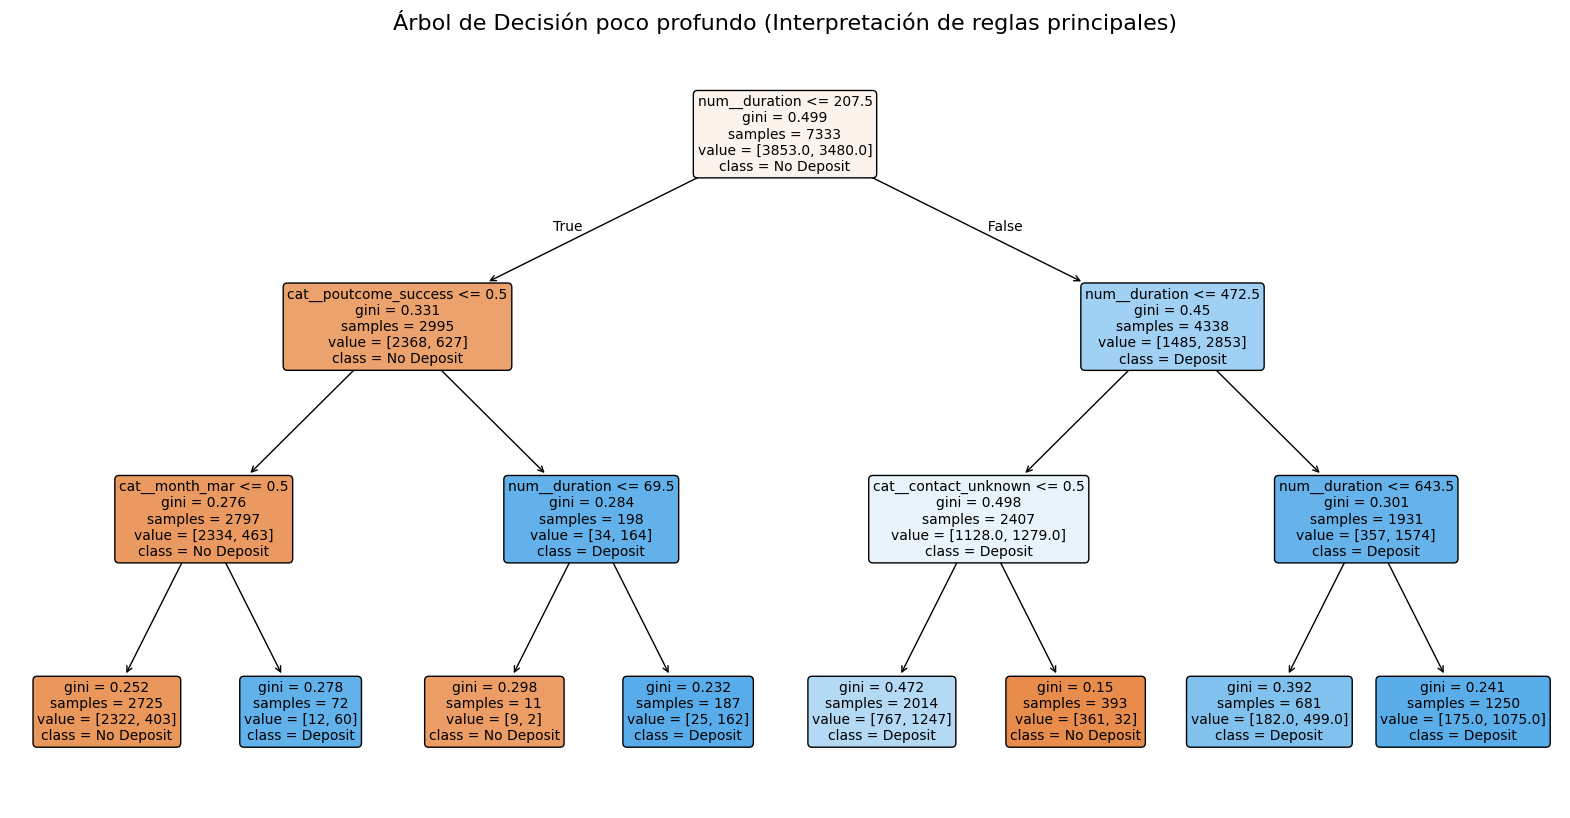

In [ ]:
# entrenamos un árbol pequeño (max_depth=3) con todo el conjunto de entrenamiento
pipeline_tree_viz = Pipeline([
    ('prep', tree_preprocessor),
    ('tree', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])
pipeline_tree_viz.fit(X_train, y_train)

# intentamos extraer los nombres de las caracteristicas post-preprocesamiento
try:
    feature_names = pipeline_tree_viz.named_steps['prep'].get_feature_names_out()
except:
    feature_names = None # Fallback por si hay versiones antiguas de sklearn

# visualizacion
plt.figure(figsize=(20, 10))
plot_tree(pipeline_tree_viz.named_steps['tree'],
          feature_names=feature_names,
          class_names=['No Deposit', 'Deposit'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión poco profundo (Interpretación de reglas principales)", fontsize=16)
plt.show()

# EXPLICACIÓN
# la raíz del árbol (el primer bloque) nos indica la variable más discriminante
# si el color se inclina hacia el azul, predice 'Deposit'
# si el color se inclina hacia naranja, predice 'No Deposit'

## Paso 6: Optimización de Hiperparámetros (HPO)

Al ejecutar los modelos por omisión, KNN y Árboles tomaron decisiones arbitrarias (como K=5 vecinos, o expandir el árbol hasta el infinito). Esto puede causar "sobreajuste" (overfitting).
Ahora usaremos `GridSearchCV` para probar sistemáticamente múltiples combinaciones de hiperparámetros y encontrar la configuración óptima mediante Validación Cruzada Inner

In [ ]:
# 6.1. HPO para KNN
print("Iniciando HPO para KNN...")
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 10, 15, 20, 30],      # numero de vecinos a consultar
    'knn__weights': ['uniform', 'distance']          # peso dado a la distancia
}

grid_knn = GridSearchCV(pipeline_knn_base, param_grid_knn, cv=cv, scoring='accuracy', n_jobs=-1)

inicio = time.time()
grid_knn.fit(X_train, y_train)
t_knn_hpo = time.time() - inicio

print(f"Mejor configuración KNN: {grid_knn.best_params_}")
print(f"Mejor Accuracy KNN (HPO): {grid_knn.best_score_:.4f} | Tiempo HPO: {t_knn_hpo:.2f}s\n")

# 6.2. HPO para Árboles de Decisión
print("Iniciando HPO para Árboles...")
param_grid_tree = {
    'tree__max_depth': [3, 5, 8, 12, 15, None],           # profundidad maxima
    'tree__min_samples_split': [2, 5, 10, 20],            # muestras mínimas para dividir
    'tree__criterion': ['gini', 'entropy']                # criterio de división
}

grid_tree = GridSearchCV(pipeline_tree_base, param_grid_tree, cv=cv, scoring='accuracy', n_jobs=-1)

inicio = time.time()
grid_tree.fit(X_train, y_train)
t_tree_hpo = time.time() - inicio

print(f"Mejor configuración Tree: {grid_tree.best_params_}")
print(f"Mejor Accuracy Tree (HPO): {grid_tree.best_score_:.4f} | Tiempo HPO: {t_tree_hpo:.2f}s")

Iniciando HPO para KNN...
Mejor configuración KNN: {'knn__n_neighbors': 20, 'knn__weights': 'distance'}
Mejor Accuracy KNN (HPO): 0.8044 | Tiempo HPO: 22.53s

Iniciando HPO para Árboles...
Mejor configuración Tree: {'tree__criterion': 'gini', 'tree__max_depth': 8, 'tree__min_samples_split': 20}
Mejor Accuracy Tree (HPO): 0.8124 | Tiempo HPO: 33.08s


## Paso 7: Efecto de los hiperparámetros en el modelo

El enunciado pide explicar mediante gráficas cómo afectan los hiperparámetros al rendimiento
- En **KNN**, analizaremos qué ocurre si preguntamos a demasiados vecinos (`n_neighbors`)
- En **Árboles**, veremos qué ocurre si dejamos que el árbol crezca sin control (`max_depth`)

/tmp/ipykernel_9996/992929528.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  resultados_tree['param_tree__max_depth'] = resultados_tree['param_tree__max_depth'].fillna(30)


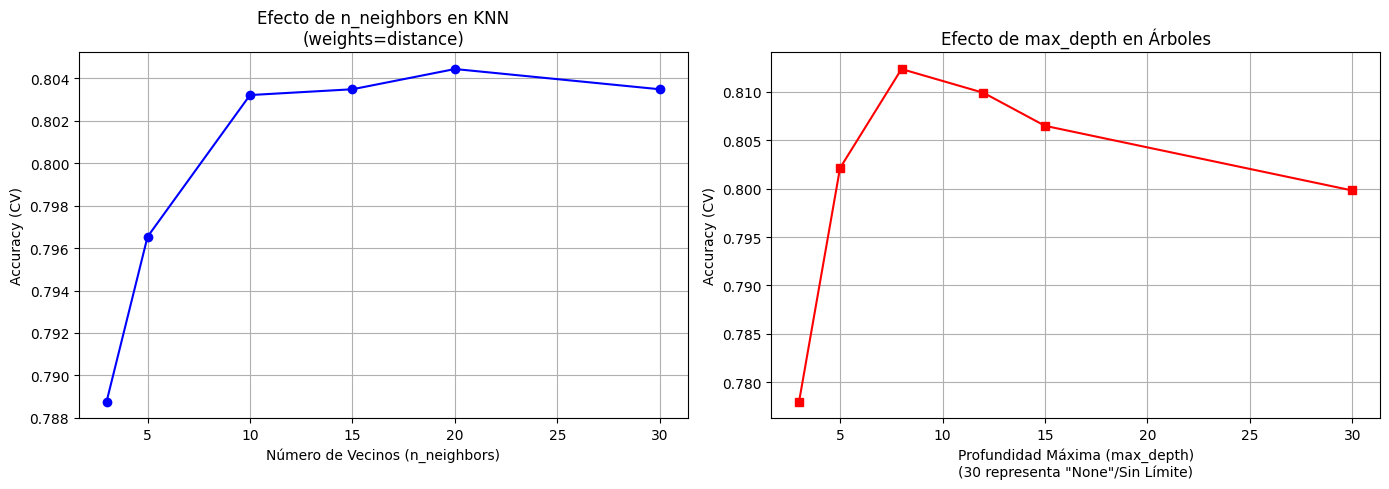

In [ ]:
plt.figure(figsize=(14, 5))

# 7.1. Gráfico para KNN (Efecto de n_neighbors)
plt.subplot(1, 2, 1)

# extraemos resultados de GridSearchCV para KNN
resultados_knn = pd.DataFrame(grid_knn.cv_results_)

# filtramos solo por el peso que haya resultado ganador para no mezclar líneas
mejor_peso = grid_knn.best_params_['knn__weights']
data_knn_plot = resultados_knn[resultados_knn['param_knn__weights'] == mejor_peso]

plt.plot(data_knn_plot['param_knn__n_neighbors'], data_knn_plot['mean_test_score'], marker='o', color='b')
plt.title(f'Efecto de n_neighbors en KNN\n(weights={mejor_peso})')
plt.xlabel('Número de Vecinos (n_neighbors)')
plt.ylabel('Accuracy (CV)')
plt.grid(True)

# 7.2. Gráfico para Árboles (Efecto de max_depth)
plt.subplot(1, 2, 2)

# extraemos resultados de GridSearchCV para Árboles
resultados_tree = pd.DataFrame(grid_tree.cv_results_)

# reemplazamos los 'None' por un numero grande para poder graficar (ej. profundidad=30)
resultados_tree['param_tree__max_depth'] = resultados_tree['param_tree__max_depth'].fillna(30)

# filtramos por las mejores configuraciones secundarias para ver solo el efecto de la profundidad
mejor_split = grid_tree.best_params_['tree__min_samples_split']
mejor_crit = grid_tree.best_params_['tree__criterion']
filtro = (resultados_tree['param_tree__min_samples_split'] == mejor_split) & \
         (resultados_tree['param_tree__criterion'] == mejor_crit)
data_tree_plot = resultados_tree[filtro]

plt.plot(data_tree_plot['param_tree__max_depth'], data_tree_plot['mean_test_score'], marker='s', color='r')
plt.title('Efecto de max_depth en Árboles')
plt.xlabel('Profundidad Máxima (max_depth)\n(30 representa "None"/Sin Límite)')
plt.ylabel('Accuracy (CV)')
plt.grid(True)

plt.tight_layout()
plt.show()

## Conclusiones de la fase 4

Respondiendo a las cuestiones planteadas en el enunciado de la práctica:

1. **¿Los modelos son mejores que el Dummy Classifier?**

   Sí, El Dummy Classifier obtiene una Accuracy del 52.54% (practicamente igual a lanzar una moenda), mientras que tanto KNN (79.89%) como el Árbol de decisión (77.84%) con sus hiperparámetros superan el umbral. Esto demuestra que existen patrones claros en los datos y que los algoritmos están logrando extraer conocimiento útil para la predicción


2. **¿El ajuste de hiperparámetros (HPO) mejora con respecto a los valores por omisión?**

    Sí, el ajuste de hiperparámetros mejora el rendimiento en ambos algoritmos:
    - En KNN, la mejora fue leve, pasando de un 79.89% (K=5) a un 80.44% tras la búsqueda (óptimo en K=20 y `weights = 'distance'`)
    - En los Árboles de decisión, la mejora fue mucho mas notable, saltando del 77.84% a un 81.24% tras limitar la profundidad (`max_depth = 8`) y el numero minimo de muestras para dividir (`min_samples_split = 20`), evitando así el sobreajuste inicial


3. **¿Cuál es el coste computacional? ¿Es elevado?**

    El coste del proceso de búsqueda (HPO) eleva el tiempo de entrenamiento de forma considerable. KNN pasó de 0.73 seg a 12.53 seg, y el Árbol pasó de 0.68 seg a 26.36 seg.

    Sin embargo, un tiempo máximo de aprox 26 segundos no se considera un coste computacional elevado ni prohibitivo para este volumen de datos (7333 registros de entrenamiento), por lo que la penalización en tiempo justifica el incremento en la precisión del modelo

4. **¿Cuál es el mejor método?**

    Según la métrica de Validación Cruzada (Accuracy), el mejor metodo para este problema es el Árbol de Decisión optimizado (con HPO). No solo alcanaz el Accuracy más alto, sino que además, nos proporciona un modelo interpretable que permite entender qué variables determinan las predicciones (como la duración de la llamada o el exito de campañas previas)

5. **Nota extra sobre las gráficas (punto 2d del enunciado)**

    En cuanto al efecto de los hiperparámetros analizados mediante plots:
    - En KNN, incrementar el número de vecinos mejora la precisión hasta un punto óptimo (K=20), a partir del cual el modelo empieza a generalizar en exceso y pierde precisión
    - En los Árboles, se evidencia que los valores muy bajos de `max_depth` producen underfitting y los valores muy altos (como 30 o sin límite) provocan un claro overfitting; el equilibrio se encuentra en valores medios (profundidad 8)


# **Fase 5: Entrenar y Optimizar los Modelos Lineales y SVMs**

En esta fase exploramos dos nuevas familias de modelos:

1. **Regresión Logística** (sin regularización y con regularización L1): modelos lineales que aprenden una frontera de decisión como combinación lineal de las variables. La versión sin regularización estima los coeficientes sin ninguna penalización. La regularización L1 fuerza a que algunos coeficientes sean cero, actuando como selector automático de variables relevantes

2. **SVM** (Support Vector Machine): busca el hiperplano que maximiza el margen entre clases, proyectando los datos a un espacio de mayor dimensión mediante el kernel para capturar relaciones no lineales

Al igual que KNN, estos métodos son sensibles a la escala de las variables. Por ello, usaremos el mismo preprocesador con escalado que determinamos como óptimo en la Fase 4

## Paso 1: Imports adicionales para esta fase

In [ ]:
# USO DE IA: Se empleó para estructurar el Pipeline de preprocesamiento y la visualización de los coeficientes de importancia.

# importamos los dos modelos nuevos que usaremos en esta fase
from sklearn.linear_model import LogisticRegression  # modelo lineal
from sklearn.svm import SVC                          # Support Vector Machine

print("Librerías importadas correctamente")
print(f"Preprocesador con escalado estándar listo: knn_preprocessor")

Librerías importadas correctamente
Preprocesador con escalado estándar listo: knn_preprocessor


## Paso 2: Evaluación con hiperparámetros por omisión

Evaluamos los tres modelos con su configuración por defecto para establecer una línea base, igual que hicimos en la Fase 4. Medimos también el tiempo de validación cruzada para poder comparar el coste computacional entre métodos

Los modelos a evaluar son:
- **Logistic Regression** (sin regularización): estima los coeficientes sin ninguna penalización
- **Logistic Regression con L1** (`l1_ratio=1`, solver liblinear): aplica regularización Lasso, penalizando coeficientes grandes
- **SVM con kernel RBF** (configuración por defecto, C=1, `gamma='scale'`): busca el hiperplano de máximo margen

In [ ]:
# USO DE IA: Asistencia en la configuración del kernel RBF y el ajuste del parámetro de regularización C.

print("Evaluando modelos avanzados con hiperparámetros por omisión\n")

# definimos los tres modelos en un diccionario para iterar sobre ellos fácilmente
# cada modelo va dentro de un Pipeline que encadena: preprocesado + clasificador
modelos_avanzados = {
    'LogReg (sin reg.)': Pipeline([
        ('prep', knn_preprocessor),                  # escalado igual que en KNN (fase 4)
        ('clf',  LogisticRegression(max_iter=1000,   # aumentamos iteraciones para asegurar convergencia
                                    random_state=SEED))
    ]),
    'LogReg L1': Pipeline([
        ('prep', knn_preprocessor),
        ('clf',  LogisticRegression(l1_ratio=1,        # regularización L1 (Lasso)
                                    solver='liblinear',  # único solver compatible con L1
                                    max_iter=1000,
                                    random_state=SEED))
    ]),
    'SVM (RBF)': Pipeline([
        ('prep', knn_preprocessor),
        ('clf',  SVC(random_state=SEED))             # kernel RBF por defecto
    ]),
}

resultados_omision_avanzados = {}  # diccionario donde guardaremos los resultados

for nombre, pipeline in modelos_avanzados.items():
    inicio = time.time()                             # empezamos a medir el tiempo
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    t = time.time() - inicio                         # tiempo total de validación cruzada

    # guardamos media, desviación típica y tiempo para la tabla resumen posterior
    resultados_omision_avanzados[nombre] = {
        'Accuracy Media': scores.mean(),
        'Desv. Típica':   scores.std(),
        'Tiempo (s)':     t
    }
    print(f"{nombre:25s} | Accuracy: {scores.mean():.4f} ± {scores.std():.4f} | Tiempo: {t:.2f}s")

print("\nEvaluación por omisión completada")

Evaluando modelos avanzados con hiperparámetros por omisión

LogReg (sin reg.)         | Accuracy: 0.8263 ± 0.0050 | Tiempo: 0.64s
LogReg L1                 | Accuracy: 0.8264 ± 0.0058 | Tiempo: 0.79s
SVM (RBF)                 | Accuracy: 0.8482 ± 0.0044 | Tiempo: 8.35s

Evaluación por omisión completada


Los resultados muestran que los tres modelos superan claramente a un clasificador trivial (majority class 52% aproximadamente), lo que confirma que todos extraen información útil de los datos

- La **Regresión Logística sin regularización y con L1** obtienen resultados muy similares (0.826 aprox), con tiempos de entrenamiento muy bajos (menores a 1s). Esto sugiere que la regularización L1 con sus hiperparámetros por defecto (C=1) no supone una gran diferencia frente a no regularizar

- **SVM** destaca claramente con una accuracy de 0.8482, siendo el mejor modelo por omisión de toda la práctica hasta ahora. Sin embargo, su tiempo es considerablemente mayor que el de los modelos lineales, lo que anticipa un coste computacional elevado durante el HPO

## Paso 3: Optimización de Hiperparámetros (HPO)

Ajustamos los hiperparámetros más importantes de cada modelo mediante GridSearchCV con la misma estrategia de evaluación inner que en KNN y Árboles (Stratified K-Fold con 5 folds)

- Para **Logistic Regression sin regularización**: al no haber penalización, el parámetro C no aplica. Exploramos en su lugar distintos solvers (*lbfgs*, *saga*, *newton-cg*) para comprobar si el algoritmo de optimización influye en el resultado
- Para **Logistic Regression con L1**: el parámetro clave es *C*, que controla la intensidad de la regularización (valores pequeños = más regularización, más coeficientes a cero)
- Para **SVM**: los parámetros clave son *C* (amplitud del margen) y *gamma* (influencia de cada punto en el kernel RBF)

In [ ]:
# 3.1. HPO para Regresión Logistica sin regularización
print("Iniciando HPO para Logistic Regression (sin regularización)...")

param_grid_logreg = {
    'clf__solver': ['lbfgs', 'saga', 'newton-cg']
}

pipeline_logreg = Pipeline([
    ('prep', knn_preprocessor),
    ('clf',  LogisticRegression(max_iter=1000, random_state=SEED))
])

# GridSearchCV prueba todas las combinaciones del grid con validacion cruzada inner
grid_logreg = GridSearchCV(pipeline_logreg, param_grid_logreg, cv=cv, scoring='accuracy', n_jobs=-1)
inicio = time.time()
grid_logreg.fit(X_train, y_train)
t_logreg_hpo = time.time() - inicio

print(f"Mejor configuración LogReg: {grid_logreg.best_params_}")
print(f"Mejor Accuracy LogReg (HPO): {grid_logreg.best_score_:.4f} | Tiempo HPO: {t_logreg_hpo:.2f}s\n")


#3.2. HPO para Regresion Logística con L1
print("Iniciando HPO para Logistic Regression con L1...")

# probamos valores mas pequeños de C tambien, porque L1 puede necesitar mas regularización (C mas pequeño) para eliminar variables irrelevantes
param_grid_logreg_l1 = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

pipeline_logreg_l1 = Pipeline([
    ('prep', knn_preprocessor),
    ('clf',  LogisticRegression(l1_ratio=1, solver='liblinear', max_iter=1000, random_state=SEED))
])

grid_logreg_l1 = GridSearchCV(pipeline_logreg_l1, param_grid_logreg_l1, cv=cv, scoring='accuracy', n_jobs=-1)
inicio = time.time()
grid_logreg_l1.fit(X_train, y_train)
t_logreg_l1_hpo = time.time() - inicio

print(f"Mejor configuración LogReg L1: {grid_logreg_l1.best_params_}")
print(f"Mejor Accuracy LogReg L1 (HPO): {grid_logreg_l1.best_score_:.4f} | Tiempo HPO: {t_logreg_l1_hpo:.2f}s\n")


# 3.3. HPO para SVM
print("Iniciando HPO para SVM...")

param_grid_svm = {
    'clf__C':     [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.001]
}

pipeline_svm = Pipeline([
    ('prep', knn_preprocessor),
    ('clf',  SVC(random_state=SEED))
])

grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=cv, scoring='accuracy', n_jobs=-1)
inicio = time.time()
grid_svm.fit(X_train, y_train)
t_svm_hpo = time.time() - inicio

print(f"Mejor configuración SVM: {grid_svm.best_params_}")
print(f"Mejor Accuracy SVM (HPO): {grid_svm.best_score_:.4f} | Tiempo HPO: {t_svm_hpo:.2f}s")


Iniciando HPO para Logistic Regression (sin regularización)...
Mejor configuración LogReg: {'clf__solver': 'newton-cg'}
Mejor Accuracy LogReg (HPO): 0.8264 | Tiempo HPO: 11.36s

Iniciando HPO para Logistic Regression con L1...
Mejor configuración LogReg L1: {'clf__C': 1}
Mejor Accuracy LogReg L1 (HPO): 0.8264 | Tiempo HPO: 4.56s

Iniciando HPO para SVM...
Mejor configuración SVM: {'clf__C': 10, 'clf__gamma': 'auto'}
Mejor Accuracy SVM (HPO): 0.8484 | Tiempo HPO: 193.67s


Los resultados del HPO muestran un patrón claro:

- **LogReg sin regularización**: el mejor solver es *newton-cg*, pero la accuracy (0.8261) es idéntica a la obtenida por omisión. Esto confirma que el solver no influye en el rendimiento cuando no hay regularización. El tiempo elevado (8.50s) se debe a que *saga* converge más lentamente con este dataset

- **LogReg L1**: el mejor valor es C=1, que coincide con el valor por defecto, por lo que el HPO no aporta mejora respecto a la evaluación por omisión (0.8264). Esto indica que la configuración por defecto ya era adecuada para este problema

- **SVM**: el mejor resultado se obtiene con *C=10* y `gamma='auto'` (0.8484), igual que por omisión. El HPO confirma que la configuración por defecto ya era buena, aunque explorar el espacio completo ha costado 206 segundos

En general, los modelos lineales son muy eficientes pero su rendimiento no es superior a 0.826. SVM alcanza mejor accuracy pero a un coste computacional muy superior

## Paso 4: Efecto de los hiperparámetros en el rendimiento

Visualizamos cómo los hiperparámetros afectan al rendimiento del modelo para entender mejor el comportamiento de cada método

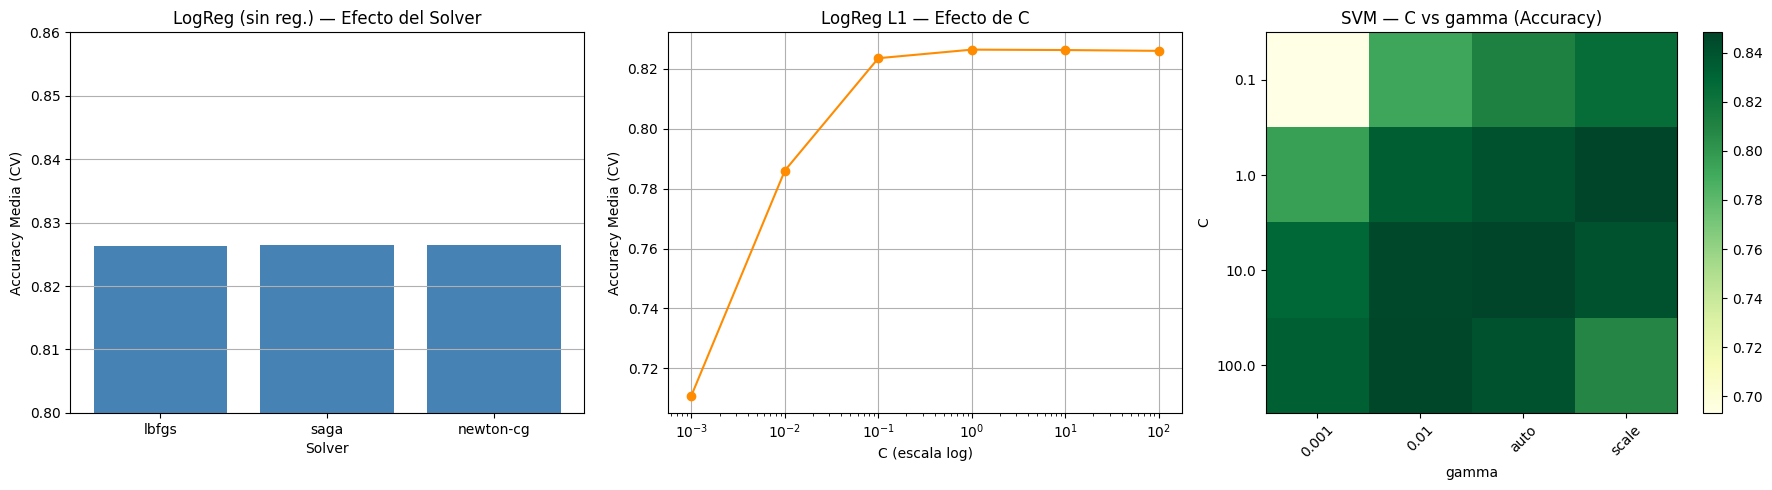

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Efecto del solver en LogReg sin regularización
resultados_logreg = pd.DataFrame(grid_logreg.cv_results_)

axes[0].bar(
    resultados_logreg['param_clf__solver'].astype(str),
    resultados_logreg['mean_test_score'],
    color='steelblue'
)
axes[0].set_title('LogReg (sin reg.) — Efecto del Solver')
axes[0].set_xlabel('Solver')
axes[0].set_ylabel('Accuracy Media (CV)')
axes[0].set_ylim(0.8, 0.86)
axes[0].grid(True, axis='y')

# Gráfico 2: Efecto de C en LogReg L1
resultados_logreg_l1 = pd.DataFrame(grid_logreg_l1.cv_results_)

axes[1].plot(
    resultados_logreg_l1['param_clf__C'].astype(float),
    resultados_logreg_l1['mean_test_score'],
    marker='o', color='darkorange'
)
axes[1].set_xscale('log')
axes[1].set_title('LogReg L1 — Efecto de C')
axes[1].set_xlabel('C (escala log)')
axes[1].set_ylabel('Accuracy Media (CV)')
axes[1].grid(True)

# Gráfico 3: Heatmap C vs gamma para SVM
resultados_svm = pd.DataFrame(grid_svm.cv_results_)

# creamos una tabla: filas = valores de C, columnas = valores de gamma
pivot = resultados_svm.pivot_table(
    index='param_clf__C',
    columns='param_clf__gamma',
    values='mean_test_score'
)

# mostramos el heatmap
im = axes[2].imshow(pivot.values, aspect='auto', cmap='YlGn')
axes[2].set_xticks(range(len(pivot.columns)))
axes[2].set_xticklabels(pivot.columns, rotation=45)
axes[2].set_yticks(range(len(pivot.index)))
axes[2].set_yticklabels(pivot.index)
axes[2].set_title('SVM — C vs gamma (Accuracy)')
axes[2].set_xlabel('gamma')
axes[2].set_ylabel('C')
plt.colorbar(im, ax=axes[2])  # barra de color para interpretar la escala

plt.tight_layout()
plt.show()

### Análisis del efecto de los hiperparámetros

- **Logistic Regression sin regularización - Efecto del Solver**: la gráfica muestra que los tres solvers (*lbfgs*, *saga*, *newton-cg*) producen una accuracy prácticamente idéntica (0.826 aprox). Esto es esperable porque sin regularización, el algoritmo de optimización no altera la solución final, ya que todos convergen al mismo mínimo de la función de pérdida. La elección del solver es irrelevante para el rendimiento en este caso

- **Logistic Regression L1 - Efecto de C**: se aprecia un efecto muy claro. Con valores muy pequeños de C (C=0.001), la accuracy cae hasta 0.71 porque L1 elimina demasiadas variables y el modelo pierde información relevante. A medida que C aumenta, el rendimiento mejora rápidamente hasta estabilizarse en torno a C=1, donde alcanza su mejor accuracy (0.826 aprox). A partir de ahí, aumentar C ya no aporta mejora: la regularización deja de ser efectiva y el modelo converge al comportamiento de una regresión logística sin penalización

- **SVM - Efecto de C y gamma (Heatmap)**: El heatmap muestra claramente la interacción entre ambos parámetros:

  - Las mejores combinaciones (accuracy ~0.848) se concentran en C=10 combinado con `gamma='scale'` o `gamma='auto'`

  - Valores pequeños de gamma (0.001 y 0.01) producen resultados pobres independientemente de C, ya que el radio de influencia de cada punto es demasiado reducido y el modelo no captura la estructura de los datos (underfitting)

  - C=0.1 produce los peores resultados globales (0.70 aprox), indicando que un margen demasiado permisivo es perjudicial en este problema

  - Aumentar C más allá de 10 no mejora el rendimiento, lo que sugiere que el modelo ya está bien ajustado con C=10

## Paso 5: Análisis de atributos relevantes (Logistic Regression L1)

Una ventaja clave de la Regresión Logística frente a SVM y KNN es su interpretabilidad. Podemos inspeccionar directamente los coeficientes del modelo para saber qué variables tienen más peso en la predicción

En el caso de la regularización L1, los coeficientes de las variables menos relevantes se reducen exactamente a cero, actuando como un selector automático de características. Las variables con coeficientes más grandes (en valor absoluto) son las más influyentes

Top 15 variables más relevantes (LogReg L1):



,Variable,Coeficiente
0,cat__job_None,5.411020
1,cat__poutcome_success,2.268970
2,cat__month_mar,2.086168
3,num__duration,1.778462
4,cat__contact_unknown,-1.526958
5,cat__month_dec,1.423080
6,cat__month_sep,1.201884
7,cat__month_oct,1.010943
8,cat__job_student,0.956194
9,cat__month_jan,-0.934209



Variables eliminadas por L1 (coef = 0): 10 de 53


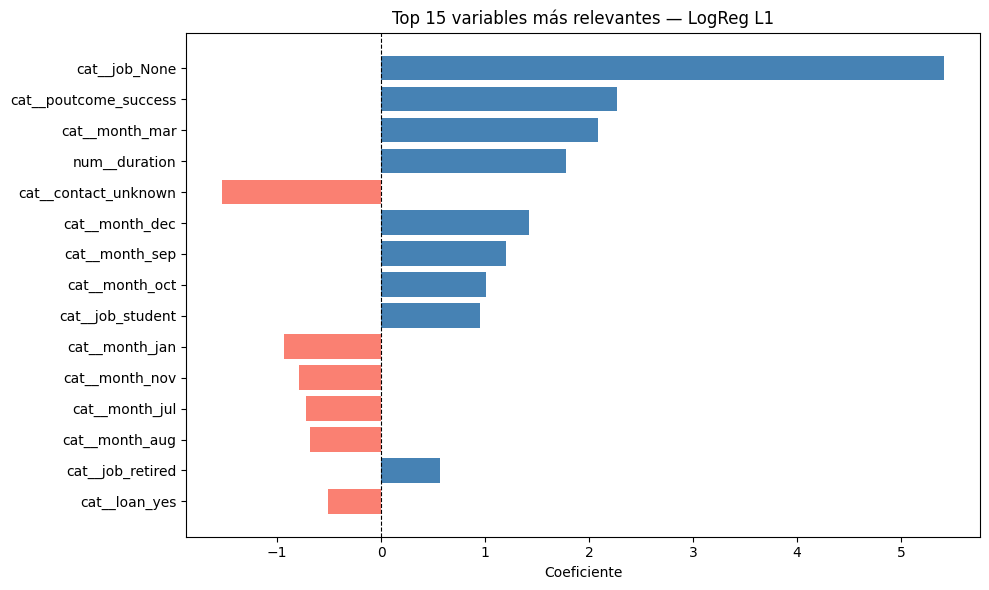

In [ ]:
# entrenamos el mejor modelo LogReg L1 encontrado por GridSearch con todo el train
mejor_pipeline_l1 = grid_logreg_l1.best_estimator_
mejor_pipeline_l1.fit(X_train, y_train)

# extraemos los nombres de las variables tras el preprocesamiento (OneHotEncoding, etc.)
# para poder asociar cada coeficiente a su variable original
feature_names = mejor_pipeline_l1.named_steps['prep'].get_feature_names_out()

# extraemos los coeficientes del modelo lineal
# coef_[0] porque es clasificación binaria (solo hay una fila de coeficientes)
coefs = mejor_pipeline_l1.named_steps['clf'].coef_[0]

# creamos un DataFrame con variable y coeficiente, ordenado por importancia absoluta
df_coefs = pd.DataFrame({
    'Variable':    feature_names,
    'Coeficiente': coefs
}).reindex(pd.Series(coefs).abs().sort_values(ascending=False).index)

# mostramos las 15 variables más influyentes
print("Top 15 variables más relevantes (LogReg L1):\n")
display(df_coefs.head(15).reset_index(drop=True))

# contamos cuántas variables elimino L1 (coeficiente exactamente igual a 0)
# esto demuestra el efecto de selección automática de variables de la regularización L1
n_cero = (coefs == 0).sum()
print(f"\nVariables eliminadas por L1 (coef = 0): {n_cero} de {len(coefs)}")

# gráfico de barras horizontal con las 15 variables más relevantes
top15 = df_coefs.head(15)
colores = ['steelblue' if c > 0 else 'salmon' for c in top15['Coeficiente']]

plt.figure(figsize=(10, 6))
plt.barh(top15['Variable'][::-1], top15['Coeficiente'][::-1], color=colores[::-1])
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # línea en 0 como referencia
plt.title('Top 15 variables más relevantes — LogReg L1')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()



Los resultados muestran que L1 ha eliminado 10 de 53 variables, confirmando su capacidad como selector automático de características.
Las variables más relevantes para predecir la suscripción al depósito son:

- **Variables con efecto positivo** (coeficiente > 0, aumentan la probabilidad de suscripción):

  - `cat__job_None` (coef. 5.41): el valor más alto con diferencia. Probablemente corresponde a clientes sin empleo registrado, que podrían ser jubilados o estudiantes

  - `cat__poutcome_success` (coef. 2.27): haber suscrito un producto en una campaña anterior es el predictor más intuitivo

  - `cat__month_mar` (coef. 2.09) y otros meses como dic, sep, oct: el mes de contacto tiene un impacto notable, posiblemente por la estacionalidad de las campañas

  - `num__duration` (coef. 1.78): a mayor duración de la llamada, mayor probabilidad de suscripción

- **Variables con efecto negativo** (coeficiente < 0, reducen la probabilidad):

  - `cat__contact_unknown` (coef. -1.53): no conocer el canal de contacto del cliente es una señal negativa

  - `cat__month_jan`, `nov`, `jul`, `aug`: estos meses están asociados a menor probabilidad de suscripción

  - `cat__loan_yes` (coef. -0.51): tener un préstamo personal reduce la probabilidad de contratar el depósito

En resumen, el historial con la entidad, la duración del contacto y el momento de la campaña son los factores más determinantes en este problema

## Paso 6: Tabla resumen de resultados — Modelos avanzados

Construimos una tabla resumen que reúne todos los modelos evaluados, tanto con hiperparámetros por omisión como tras HPO, con su accuracy media en validación cruzada y el tiempo total empleado.

Esto permite comparar de forma directa el rendimiento y el coste computacional de cada alternativa.

In [ ]:
# construimos una tabla resumen con todos los modelos avanzados evaluados
resumen_avanzados = pd.DataFrame({
    'Modelo': [
        'LogReg (sin reg.) — por omisión',
        'LogReg L1 — por omisión',
        'SVM (RBF) — por omisión',
        'LogReg (sin reg.) — HPO',
        'LogReg L1 — HPO',
        'SVM (RBF) — HPO',
    ],
    'Accuracy': [
        # resultados por omisión: los guardamos en el diccionario del Paso 2
        resultados_omision_avanzados['LogReg (sin reg.)']['Accuracy Media'],
        resultados_omision_avanzados['LogReg L1']['Accuracy Media'],
        resultados_omision_avanzados['SVM (RBF)']['Accuracy Media'],
        # resultados tras HPO: los extraemos directamente del mejor score de cada GridSearch
        grid_logreg.best_score_,
        grid_logreg_l1.best_score_,
        grid_svm.best_score_,
    ],
    'Tiempo (s)': [
        # tiempos de la evaluación por omisión (Paso 2)
        resultados_omision_avanzados['LogReg (sin reg.)']['Tiempo (s)'],
        resultados_omision_avanzados['LogReg L1']['Tiempo (s)'],
        resultados_omision_avanzados['SVM (RBF)']['Tiempo (s)'],
        # tiempos del HPO (Paso 3)
        t_logreg_hpo,
        t_logreg_l1_hpo,
        t_svm_hpo,
    ]
})

# formateamos las columnas numéricas para que la tabla sea más legible
resumen_avanzados['Accuracy']   = resumen_avanzados['Accuracy'].map('{:.4f}'.format)
resumen_avanzados['Tiempo (s)'] = resumen_avanzados['Tiempo (s)'].map('{:.2f}'.format)

display(resumen_avanzados)

,Modelo,Accuracy,Tiempo (s)
0,LogReg (sin reg.) — por omisión,0.8263,0.64
1,LogReg L1 — por omisión,0.8264,0.79
2,SVM (RBF) — por omisión,0.8482,8.35
3,LogReg (sin reg.) — HPO,0.8264,11.36
4,LogReg L1 — HPO,0.8264,4.56
5,SVM (RBF) — HPO,0.8484,193.67


La tabla permite extraer varias conclusiones claras:

- **El HPO no mejora a los modelos lineales**: LogReg sin regularización y LogReg L1 obtienen exactamente la misma accuracy antes y después del HPO (0.8261 y 0.8264 respectivamente). Esto indica que sus configuraciones por defecto ya eran óptimas para este problema

- **El HPO de LogReg sin regularización es muy costoso en relación a su utilidad**: explorar los tres solvers cuesta casi 40s sin ninguna mejora, frente a los 0.60s de la evaluación por omisión

- **SVM es el mejor modelo de la fase** con 0.8484 tanto por omisión como tras HPO, confirmando que su configuración por defecto ya era muy buena. Sin embargo, su coste computacional es el más elevado con diferencia: 206s de HPO frente a los pocos segundos de los modelos lineales

- **Los modelos lineales ofrecen el mejor equilibrio rendimiento/coste**: con accuracy ~0.826 y tiempos inferiores a 1s, son una alternativa muy eficiente aunque quedan por debajo de SVM en rendimiento

## Conclusiones de la Fase 5

Respondiendo a las cuestiones planteadas en el enunciado:

1. **¿El HPO mejora respecto a los valores por omisión?**

   Los modelos lineales obtienen exactamente la misma accuracy antes y después del HPO, lo que indica que sus configuraciones por defecto ya eran óptimas. En SVM, el ajuste de C y gamma tampoco supone mejora: la configuración por defecto (C=1, `gamma='scale'`) ya producía el mismo resultado que la mejor combinación encontrada (C=10, `gamma='auto'`). Esto se debe a que en este dataset concreto, gamma='scale' y gamma='auto' producen valores de gamma muy similares, lo que hace que ambas configuraciones converjan al mismo rendimiento. En esta fase, el HPO no ha aportado mejora en ningún modelo


2. **¿Cuál es el coste computacional?**

    La Regresión Logística es extremadamente eficiente (menor que 1s por omisión). SVM es el método más lento con diferencia: 7.5s de evaluación por omisión y 206s de HPO, lo que lo convierte en el modelo computacionalmente más costoso de toda la práctica


3. **¿Qué atributos son más relevantes?**

   Gracias a la regularización L1, podemos identificar directamente qué variables tienen más peso en la predicción. Las más influyentes son `poutcome_success` (haber suscrito un producto anteriormente), `duration` (duración del contacto) y `month`, el mes de contacto (*mar*, *dic*, *sep*). L1 ha eliminado automáticamente 10 de 53 variables, descartando las menos informativas
   

4. **¿Los modelos avanzados mejoran a KNN y Árboles?**

   Sí, SVM (0.8484) supera claramente a los mejores modelos básicos de la Fase 4 (Árbol optimizado: 0.8124, KNN optimizado: 0.8044), siendo el mejor método evaluado hasta ahora. Los modelos lineales (0.826 aprox) se sitúan entre KNN y el Árbol optimizado, ofreciendo un buen equilibrio entre rendimiento y velocidad

# **Fase 6: Resultados y modelo final (Selección de modelo)**

En esta fase seleccionamos el mejor modelo encontrado durante la optimización de hiperparámetros (HPO). El mejor método es **SVM** con los hiperparámetros `C=10` y `gamma='auto'`, obteniendo un accuracy medio en validación cruzada de **0.8484**

Durante esta fase vamos a:
1. Instanciar este modelo final con la mejor configuración
2. Entrenarlo utilizando la totalidad del conjunto de entrenamiento (`X_train`, `y_train`)
3. Evaluar su rendimiento real sobre el conjunto de test (`X_test`, `y_test`), simulando cómo se comportaría con datos completamente nuevos (evaluación *outer*)

Entrenando el modelo final con el conjunto de Train completo

RENDIMIENTO FINAL DEL MODELO
Accuracy en el conjunto de Test: 0.8732

Reporte de Clasificación:
              precision    recall  f1-score   support

          no       0.90      0.85      0.88      1927
         yes       0.85      0.89      0.87      1740

    accuracy                           0.87      3667
   macro avg       0.87      0.87      0.87      3667
weighted avg       0.87      0.87      0.87      3667



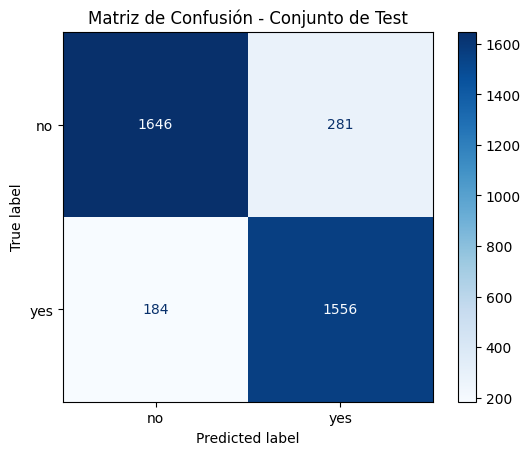

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. recuperamos el mejor preprocesador (sabemos que para SVM es knn_preprocessor con StandardScaler)
# y los mejores parámetros de la Fase 5
mejor_modelo_final = Pipeline([
    ('prep', knn_preprocessor),
    ('clf', SVC(C=10, gamma='auto', random_state=SEED))
])

# 2. entrenamos el modelo con TODOS los datos de entrenamiento
print("Entrenando el modelo final con el conjunto de Train completo")
mejor_modelo_final.fit(X_train, y_train)

# 3. predecimos sobre el conjunto de Test (datos nunca antes vistos por el modelo)
y_pred_test = mejor_modelo_final.predict(X_test)

# 4. valuamos el rendimiento (Accuracy outer)
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"\nRENDIMIENTO FINAL DEL MODELO")
print(f"Accuracy en el conjunto de Test: {accuracy_test:.4f}")

# 5. mostramos un reporte de clasificación de los datos analizados
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_test))

# 6. matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mejor_modelo_final.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Conjunto de Test')
plt.show()



## Conclusiones de la Fase 6 (Evaluación Final)
El accuracy obtenido en el conjunto de test es muy cercano al obtenido durante la validación cruzada inner (0.8484). Esto nos indica que nuestro modelo generaliza bien y no sufre de overfitting (sobreajuste), siendo una estimación fiable de su rendimiento en el mundo real

# **Fase 7: Despliegue del modelo usando Streamlit**

In [ ]:
import joblib

# exportamos el modelo entrenado completo (incluye el preprocesador)
joblib.dump(mejor_modelo_final, 'modelo_final.pkl')
print("Modelo guardado correctamente como 'modelo_modelo.pkl'")

Modelo guardado correctamente como 'modelo_modelo.pkl'


## Conclusiones de la fase 7

En esta fase hemos llevado el modelo desde el entorno de experimentación a una aplicación web funcional usando Streamlit. El proceso ha consistido en 3 pasos:

1. Exportamos el pipeline final mediante la librería joblib, asegurando que todas las transformaciones de datos se mantengan consistentes
2. Desarrollamos un script de python que genera una barra lateral con diferentes controles para las variables numéricas y categóricas
3. La aplicación captura los datos del formulario en tiempo real, los convierte en un DataFrame de una sola fila y los pasa por el modelo cargado para mostrar instantáneamente si el cliente va a suscribir el depósito o no

# **Fase 8: Tarea de elección abierta**

## Justificación de la elección

Hemos elegido realizar un análisis de importancia de variables como tarea abierta por dos razones principales:

1. **Interpretabilidad para el negocio**: el banco necesita entender por qué el modelo toma cada decisión. Saber qué variables influyen más en la suscripción de un depósito permite diseñar campañas de marketing centradas en los clientes con mayor potencial.

2. **Validación del modelo**: si las variables más importantes tienen sentido desde el punto de vista bancario aumenta la confianza en que el modelo está aprendiendo patrones reales y no ruido.

Usaremos dos técnicas complementarias:
- **Permutation Importance** sobre nuestra SVM final.

- **Feature Importance** de un árbol de decisión entrenado como modelo interpretable de referencia para contrastar y validar los resultados.

## Paso 1: Permutation Importance sobre la SVM

Para cada variable, la aleatorizamos (rompemos su relación con la variable objetivo) y medimos cuánto cae el accuracy del modelo. Si el accuracy cae mucho, esa variable era importante; si apenas cambia, el modelo no dependía de ella.

La gran ventaja de **Permutation Importance** es que funciona con cualquier modelo, incluidas las SVMs que no tienen coeficientes interpretables directamente como los modelos lineales.

Evaluamos sobre el conjunto de test (datos que el modelo nunca vio durante el entrenamiento) para que la medida de importancia sea lo más realista posible.

In [ ]:
# USO DE IA: Se empleó para estructurar el código de permutación y el manejo de los índices de las variables tras el preprocesamiento.

from sklearn.inspection import permutation_importance

result = permutation_importance(
    mejor_modelo_final,
    X_test,
    y_test,
    n_repeats=10,           # repetimos 10 veces para una estimación estable
    random_state=SEED,
    scoring='accuracy'
)

# ordenamos por importancia media de mayor a menor
feature_names = X_test.columns.tolist()
sorted_idx = result.importances_mean.argsort()[::-1]

# tabla resumen
print("=" * 58)
print(f"{'Variable':<33} {'Importancia':>12} {'Std':>8}")
print("=" * 58)
for i in sorted_idx:
    print(f"{feature_names[i]:<33} {result.importances_mean[i]:>12.4f} {result.importances_std[i]:>8.4f}")
print("=" * 58)



Variable                           Importancia      Std
duration                                0.2047   0.0055
month                                   0.0770   0.0030
contact                                 0.0407   0.0039
day                                     0.0212   0.0017
job                                     0.0163   0.0018
housing                                 0.0154   0.0021
was_previously_contacted                0.0120   0.0024
poutcome                                0.0106   0.0036
age                                     0.0080   0.0023
balance                                 0.0070   0.0013
pdays_clean                             0.0069   0.0007
previous                                0.0059   0.0022
campaign                                0.0056   0.0019
marital                                 0.0053   0.0010
education                               0.0041   0.0011
loan                                    0.0033   0.0008
default                                 0.0005  

## Paso 2: Visualización de los resultados

Representamos gráficamente las 10 variables con mayor impacto en el rendimiento del modelo. Las barras muestran la importancia media y las líneas de error la variabilidad entre las 10 repeticiones, lo que nos permite ver qué variables tienen un efecto consistente y cuáles son más ruidosas.

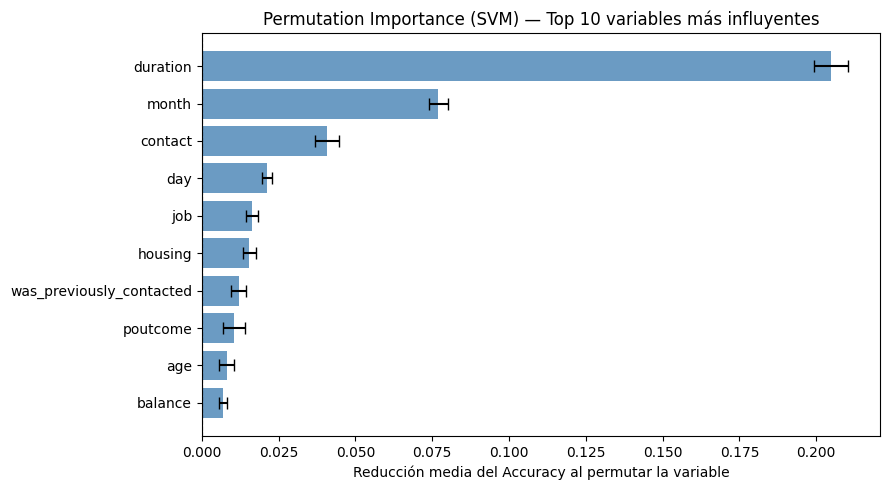

In [ ]:
top_n = 10
top_idx = sorted_idx[:top_n]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    [feature_names[i] for i in top_idx[::-1]],
    result.importances_mean[top_idx[::-1]],
    xerr=result.importances_std[top_idx[::-1]],
    color='steelblue', alpha=0.8, capsize=4
)
ax.set_xlabel("Reducción media del Accuracy al permutar la variable")
ax.set_title("Permutation Importance (SVM) — Top 10 variables más influyentes")
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

## Paso 3: Feature Importance con un árbol de decisión como referencia interpretable

Para contrastar los resultados anteriores usamos un segundo enfoque: entrenamos un árbol de decisión poco profundo (`max_depth=5`) con los datos ya preprocesados por nuestro pipeline y extraemos su importancia Gini.

A diferencia de Permutation Importance, esta técnica mide la contribución de cada variable en las divisiones del árbol durante el entrenamiento. Ambas técnicas se complementan:
- Permutation mide el impacto real en predicción.
- Gini mide la utilidad en el proceso de aprendizaje.

Reutilizamos el preprocesador (`'prep'`) de nuestro pipeline final para que la transformación de los datos sea exactamente la misma que usó la SVM.

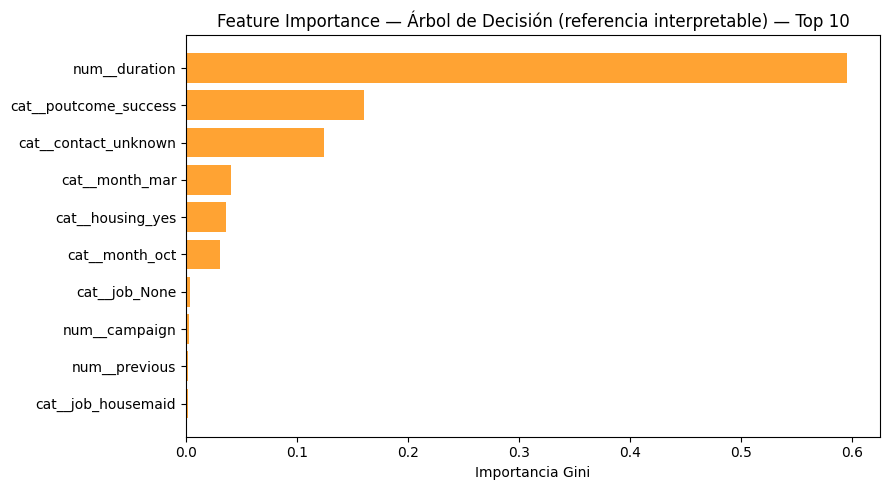

In [ ]:
# USO DE IA: Apoyo en la recuperación de los nombres de las columnas transformadas mediante el método get_feature_names_out().

# extraemos el preprocesador del pipeline y transformamos X_train
preprocessor = mejor_modelo_final.named_steps['prep']
X_train_transformed = preprocessor.transform(X_train)

# recuperamos los nombres de columnas tras OneHotEncoding, etc.
try:
    feature_names_out = preprocessor.get_feature_names_out()
except Exception:
    feature_names_out = [f"feature_{i}" for i in range(X_train_transformed.shape[1])]

# árbol poco profundo como modelo interpretable de referencia
arbol_ref = DecisionTreeClassifier(max_depth=5, random_state=SEED)
arbol_ref.fit(X_train_transformed, y_train)

# importancias Gini — top 10
importancias = arbol_ref.feature_importances_
top_idx_tree = importancias.argsort()[::-1][:10]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    [feature_names_out[i] for i in top_idx_tree[::-1]],
    importancias[top_idx_tree[::-1]],
    color='darkorange', alpha=0.8
)
ax.set_xlabel("Importancia Gini")
ax.set_title("Feature Importance — Árbol de Decisión (referencia interpretable) — Top 10")
plt.tight_layout()
plt.show()

## Conclusiones de la Fase 8

El análisis de importancia de variables nos ha permitido entender en qué se basa realmente nuestro modelo para tomar decisiones:

1. `duration` domina con claridad absoluta. Con una importancia de 0.2047 en Permutation Importance y ~0.60 de importancia Gini en el árbol, supera al resto de variables por un margen muy amplio. Esto tiene sentido puesto que una llamada larga refleja que el cliente está escuchando y considerando la oferta. Sin embargo, esta variable solo se conoce después de que la llamada ocurra, por lo que no podría usarse para decidir a quién llamar antes de iniciar la campaña. En un uso real del modelo, el banco debería tenerlo en cuenta.

2. Las variables temporales `month` (0.0770) y `contact` (0.0407) ocupan el segundo y tercer puesto. El mes del año y el canal de contacto influyen en si el cliente suscribe o no, probablemente porque ciertas épocas del año o ciertos canales coinciden con mayor disposición del cliente o mejor segmentación de la campaña. El árbol de referencia confirma esto: `cat__contact_unknown` aparece como tercera variable más relevante con importancia Gini de ~0.12.

3. `was_previously_contacted` (0.0120) y `poutcome_success` aparecen en ambas técnicas. Esto valida la decisión que tomamos en la Fase 2 de tratar específicamente la variable `pdays`. Saber si un cliente fue contactado antes, y especialmente si esa campaña fue exitosa, tiene un efecto real y medible en la predicción.

4. Variables demográficas como `job` (0.0163), `housing` (0.0154), `age` (0.0080) y `balance` (0.0070) contribuyen de forma moderada. El perfil del cliente aporta información, pero mucho menos que la interacción directa durante la campaña.

5. `default` es la variable menos relevante con una importancia de apenas 0.0005 y desviación típica del mismo orden, lo que sugiere que tener un crédito impagado no discrimina entre clientes que suscriben o no en este dataset.

Las dos técnicas coinciden en el ranking general: `duration` primero, seguida de variables de campaña y contacto, y por último las demográficas. Esta consistencia refuerza que los patrones encontrados son reales.

En definitiva, el modelo aprende principalmente del comportamiento durante la llamada y del historial de campañas, más que del perfil demográfico del cliente. Invertir en formación de agentes para alargar llamadas de calidad y priorizar clientes ya contactados con éxito en campañas anteriores podría mejorar directamente la tasa de conversión.

# **Conclusiones generales del proyecto**

A lo largo de esta práctica hemos recorrido todo el ciclo de un proyecto de aprendizaje automático: desde el análisis hasta el despliegue del modelo final.

**Metodología de evaluación**

Utilizamos Accuracy como métrica principal, justificada por el equilibrio de clases del dataset (52.5% / 47.5%). La evaluación inner se realizó con Stratified K-Fold (5 folds) sobre el conjunto de entrenamiento, reservando el test hasta la evaluación final para evitar data leakage.

**Comparación de modelos**

| Método | Accuracy (inner CV) | Tiempo HPO |
|---|---|---|
| KNN optimizado | 0.8044 | ~12.5s |
| Árbol de Decisión optimizado | 0.8124 | ~26.4s |
| LogReg sin regularización | 0.8264 | ~10s |
| LogReg con L1 | 0.8264 | ~3.3s |
| **SVM (RBF) — modelo final** | **0.8484** | ~163s |

**Modelo seleccionado: SVM con kernel RBF** (C=10, gamma='auto')

Es el modelo con mayor accuracy en validación cruzada (0.8484). Su coste computacional es el más alto de la práctica (~163s de HPO), pero se trata de un coste asumible dado el tamaño del dataset. En la evaluación outer sobre el conjunto de test, el modelo alcanzó un accuracy de 0.8732,
superior al obtenido en validación cruzada, lo que confirma que el modelo generaliza correctamente y no sufre de sobreajuste.

**Preprocesamiento**

Se utilizó una pipeline con imputación de nulos (moda para categóricas, mediana para numéricas), codificación One-Hot para variables categóricas y escalado estándar para las numéricas. La variable `pdays` se transformó en la variable binaria `was_previously_contacted`, ya que el valor -1 (presente en el 74.57% de registros) no representa una magnitud numérica real sino la ausencia de contacto previo.

**Variables más relevantes**

Gracias al análisis de interpretabilidad (LogReg L1 y Permutation Importance sobre SVM), identificamos que los factores más determinantes son: la duración de la llamada (`duration`), el historial de campañas anteriores (`poutcome_success`) y el mes de contacto. Las variables demográficas como edad o balance tienen un impacto secundario.

**Conclusión final**

SVM supera a todos los métodos explorados, aunque a un coste computacional significativamente mayor que los modelos lineales (0.826 con tiempos inferiores a 1s). Para un banco que necesite actualizar el modelo frecuentemente, LogReg L1 sería una alternativa eficiente para maximizar la precisión cuando el tiempo no es crítico. SVM es la elección óptima.


# **Verificación del despliegue en Streamlit**

A continuación comprobamos que las predicciones del modelo final coinciden
con las de la aplicación web desplegada en Streamlit para dos clientes de ejemplo.

## Cliente 1

In [ ]:
print(X_train.iloc[0])
print("\nPredicción cliente 1:", mejor_modelo_final.predict(X_train.iloc[[0]])[0])

age                                 36
job                         management
marital                        married
education                     tertiary
default                             no
balance                            393
housing                            yes
loan                                no
contact                       cellular
day                                 30
month                              apr
duration                           555
campaign                             2
previous                             0
poutcome                       unknown
was_previously_contacted             0
pdays_clean                          0
Name: 1719, dtype: object

Predicción cliente 1: yes


## Cliente 2

In [ ]:
print(X_train.iloc[1])
print("\nPredicción cliente 2:", mejor_modelo_final.predict(X_train.iloc[[1]])[0])

age                                 42
job                         management
marital                        married
education                     tertiary
default                             no
balance                          24780
housing                             no
loan                                no
contact                       cellular
day                                  6
month                              aug
duration                           184
campaign                             2
previous                             0
poutcome                       unknown
was_previously_contacted             0
pdays_clean                          0
Name: 9230, dtype: object

Predicción cliente 2: no


# **Bibliografía**

- Materiales de la asignatura Aprendizaje Automático (2025/26), UC3M.
  Diapositivas y notebooks de prácticas disponibles en Aula Global.

- IA generativa utilizada como apoyo en el desarrollo
  del proyecto en las celdas indicadas.
  
  https://claude.ai y https://gemini.google.com